# carGO PH — Line Plot of IoT Sensor Readings Over Time

**Week:** 7 — Line Plot of IoT Sensor Readings Over Time <br>
**Description:** Visualizes the cleaned IoT sensor data produced in Week 6 (`iot_cleaned_data.csv`). Each sensor type — GPS, Temperature, and RFID — is plotted in its own colored panel against the original sensor capture time, making patterns, trends, and anomalies easy to read.

## 1. Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Visualization style (template step: sns.set(style="whitegrid"))
sns.set_theme(style="whitegrid")

# One fixed color per sensor type — reused across every panel and the legend
SENSOR_COLORS = {
    "GPS":         "#1f77b4",  # blue
    "Temperature": "#d62728",  # red
    "RFID":        "#2ca02c",  # green
}

## 2. Load Cleaned Data

In [7]:
# Access preprocessed data from Homework No. 3 (Week 6 export)
df = pd.read_csv("../data/iot_cleaned_data.csv")

# Convert timestamp columns to datetime for proper time-axis plotting
df["sensor_timestamp"]     = pd.to_datetime(df["sensor_timestamp"])
df["blockchain_timestamp"] = pd.to_datetime(df["blockchain_timestamp"])

# Sort chronologically so the lines connect points in time order
df = df.sort_values("sensor_timestamp").reset_index(drop=True)

print(f"Loaded {len(df)} records")
print("Sensor types:", df["sensor_type"].value_counts().to_dict())
print("Time range  :", df['sensor_timestamp'].min(), "→", df['sensor_timestamp'].max())
df.head()

Loaded 329 records
Sensor types: {'GPS': 150, 'Temperature': 95, 'RFID': 84}
Time range  : 2026-05-03 07:00:00 → 2026-05-05 13:00:00


,blockchain_timestamp,sensor_timestamp,rfid_tag,device_id,sensor_type,latitude,longitude,scan_status,temperature_c,is_flagged,temp_breach,goods_category,origin,destination
0,2026-06-04 16:21:45,2026-05-03 07:00:00,RFID-020,GPS291,GPS,14.601956,120.989036,NaN,NaN,False,NaN,Industrial,Paco,Pandacan
1,2026-06-04 16:21:45,2026-05-03 07:00:00,RFID-011,TMP104,Temperature,NaN,NaN,NaN,12.2,False,False,Cool-Chain,Sampaloc,Santa Ana
2,2026-06-04 16:21:46,2026-05-03 07:00:00,RFID-011,GPS728,GPS,14.620032,120.962165,NaN,NaN,False,NaN,Cool-Chain,Sampaloc,Santa Ana
3,2026-06-04 16:21:47,2026-05-03 08:00:00,RFID-011,RFD702,RFID,NaN,NaN,VERIFIED,NaN,False,NaN,Cool-Chain,Sampaloc,Santa Ana
4,2026-06-04 16:21:48,2026-05-03 09:00:00,RFID-020,GPS920,GPS,14.595757,120.981906,NaN,NaN,False,NaN,Industrial,Paco,Pandacan


## 3. Line Plot — One Panel Per Sensor Type
Three stacked panels sharing a common time axis:

| Panel | Sensor | Y-axis | What it shows |
|-------|--------|--------|----------------|
| 1 | **GPS** | Latitude (°N) | Northward movement of shipments over time |
| 2 | **Temperature** | °C | Cold-chain readings; the dashed line at 0°C separates frozen from chilled goods |
| 3 | **RFID** | Flagged scans per hour | Checkpoint anomalies aggregated hourly |

GPS and Temperature are plotted per shipment (`units="rfid_tag"`) so each line follows one shipment's own readings instead of seaborn averaging across shipments at shared timestamps. RFID status is text (`VERIFIED`/`FLAGGED`), so it is encoded into an hourly count of flagged scans to give a meaningful line. Temperature breach markers (✕) are overlaid only on Panel 2 because `temp_breach` is a concept exclusive to temperature-regulated shipments — GPS has no equivalent threshold violation, and RFID already encodes anomalies through its flagged scan count in Panel 3.

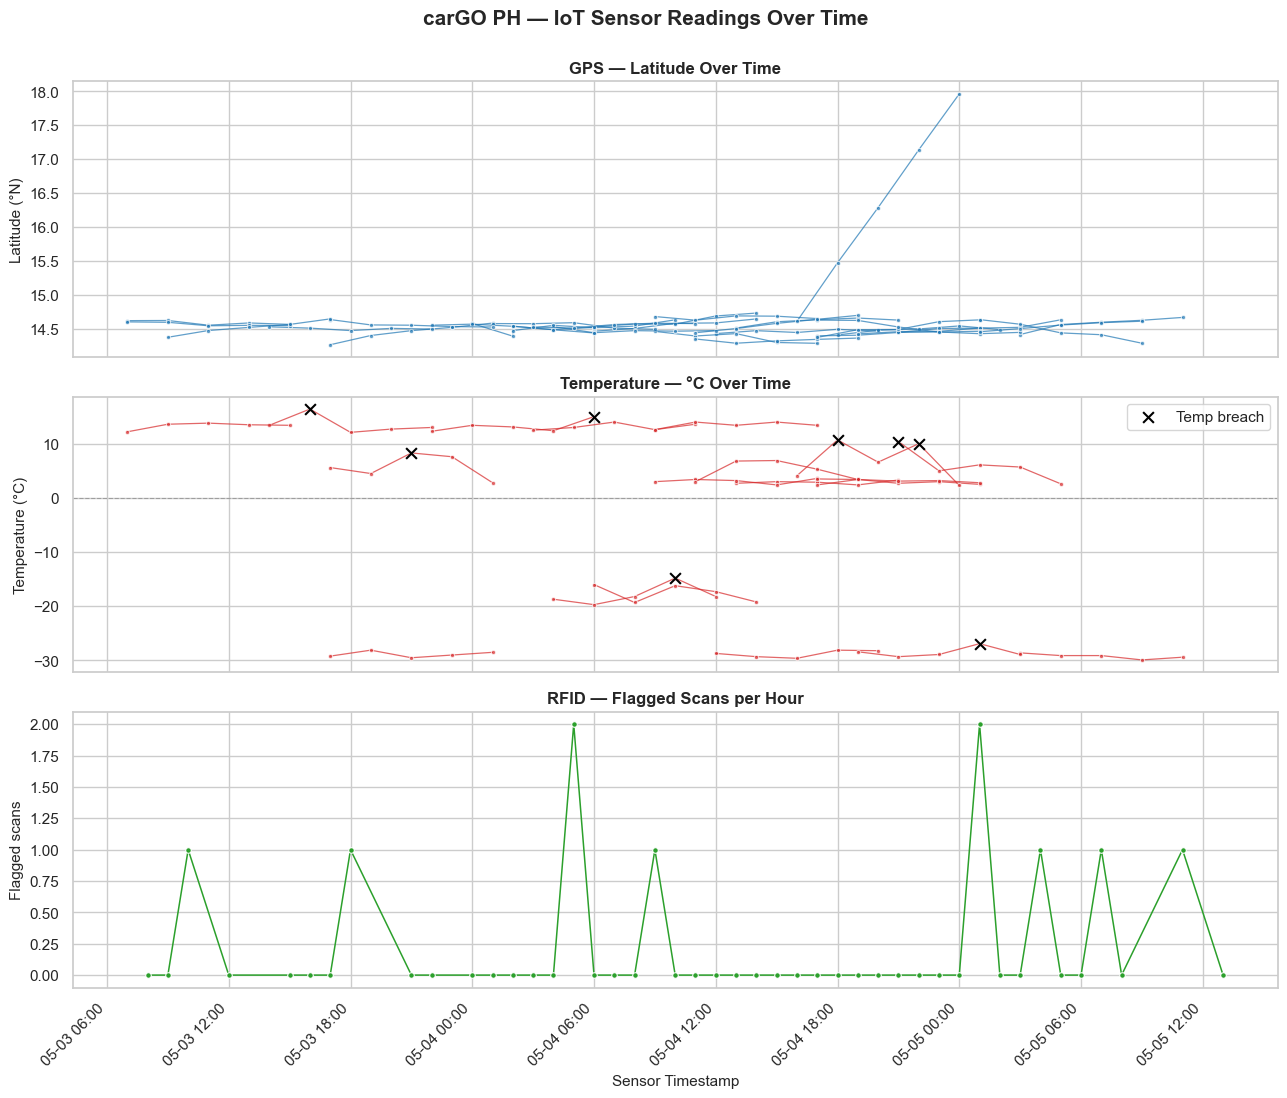

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

# ── Panel 1: GPS latitude ────────────────────────────────────
gps = df[df["sensor_type"] == "GPS"]
sns.lineplot(
    data=gps, x="sensor_timestamp", y="latitude",
    units="rfid_tag", estimator=None,           # one line per shipment, no averaging
    ax=axes[0], color=SENSOR_COLORS["GPS"],
    marker="o", markersize=3, linewidth=0.9, alpha=0.7,
)
axes[0].set_title("GPS — Latitude Over Time", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Latitude (°N)", fontsize=11)

# ── Panel 2: Temperature °C ─────────────────────────────────
temp = df[df["sensor_type"] == "Temperature"]
sns.lineplot(
    data=temp, x="sensor_timestamp", y="temperature_c",
    units="rfid_tag", estimator=None,
    ax=axes[1], color=SENSOR_COLORS["Temperature"],
    marker="o", markersize=3, linewidth=0.9, alpha=0.7,
)
axes[1].set_title("Temperature — °C Over Time", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Temperature (°C)", fontsize=11)
axes[1].axhline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
# Overlay breach markers
breaches = temp[temp["temp_breach"] == True]
axes[1].scatter(breaches["sensor_timestamp"], breaches["temperature_c"],
                color="black", marker="x", s=60, zorder=5, label="Temp breach")
axes[1].legend()

# ── Panel 3: RFID flagged scans per hour ────────────────────────
rfid = df[df["sensor_type"] == "RFID"].copy()
rfid_hourly = (
    rfid.assign(hour=rfid["sensor_timestamp"].dt.floor("h"))
        .groupby("hour")["is_flagged"].sum()
        .reset_index()
)
sns.lineplot(
    data=rfid_hourly, x="hour", y="is_flagged",
    ax=axes[2], color=SENSOR_COLORS["RFID"],
    marker="o", markersize=4, linewidth=1.1,
)
axes[2].set_title("RFID — Flagged Scans per Hour", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Flagged scans", fontsize=11)
axes[2].set_xlabel("Sensor Timestamp", fontsize=11)

# ── Shared x-axis formatting ────────────────────────────────
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.setp(axes[2].get_xticklabels(), rotation=45, ha="right")

fig.suptitle("carGO PH — IoT Sensor Readings Over Time",
             fontsize=15, fontweight="bold", y=0.997)
plt.tight_layout()
plt.show()

### Analysis: IoT Sensor Readings Over Time

**GPS — Latitude Over Time**
Most shipments stay within Metro Manila/NCR, which appears as the tight bundle of
flat lines hovering around 14.3°N–14.7°N. One shipment (RFID-023, Bel-Air →
Canagatan) stands out with a sharp spike up to ~18°N — a location far north of
Metro Manila, closer to Cagayan Valley. This is a GPS anomaly included for testing.
Routes with little movement show up as nearly flat lines, which makes sense for
short city deliveries.

**Temperature — °C Over Time**
The chart shows three clear groups of lines, each matching a type of cargo:
- **Top group (~10°C to 16°C):** Cool-Chain and Pharma shipments. A few readings
  went slightly above the allowed limit, marking those moments as temperature
  breaches — meaning the cargo got warmer than it should have.
- **Middle group (~−14°C to −20°C):** Frozen goods. One reading crept too warm
  at ~−14.8°C, which counts as a breach since frozen cargo must stay at −16°C
  or colder.
- **Bottom group (~−26°C to −30°C):** Deep Freeze shipments. Most stayed within
  the safe range, but one reading at ~−26.9°C was too warm and triggered a breach.

The dashed line at 0°C acts as a visual divider between frozen and refrigerated
cargo, making the three groups easy to tell apart at a glance.

**RFID — Flagged Scans per Hour**
Most of the time, the line stays flat at zero — meaning checkpoints were clear.
The spikes show hours when one or more shipments were flagged at a checkpoint.
A spike reaching 2.0 means two shipments were flagged in the same hour. Since
the spikes are few and scattered, this looks like normal, isolated incidents
rather than a widespread problem.

**Overall**
The chart covers about 2.5 days of deliveries (May 3–5), with most activity in
the first 24 hours. The main things to look into are the GPS spike on RFID-023
and the handful of temperature breaches — these are the kinds of issues a
logistics team would want to catch and investigate early.

## 4. (Optional) Template-Style Single Plot
For direct comparison with the code template, this cell overlays GPS and Temperature on one axis with `hue="sensor_type"`. It is kept separate because the differing scales make it harder to read — the faceted version above is the primary deliverable. RFID is excluded here since, unlike Panel 3 in Section 3 where flagged scans are aggregated into hourly counts, this overlay plots raw per-shipment readings and RFID has no equivalent raw numeric value to share the Y-axis with GPS and Temperature.

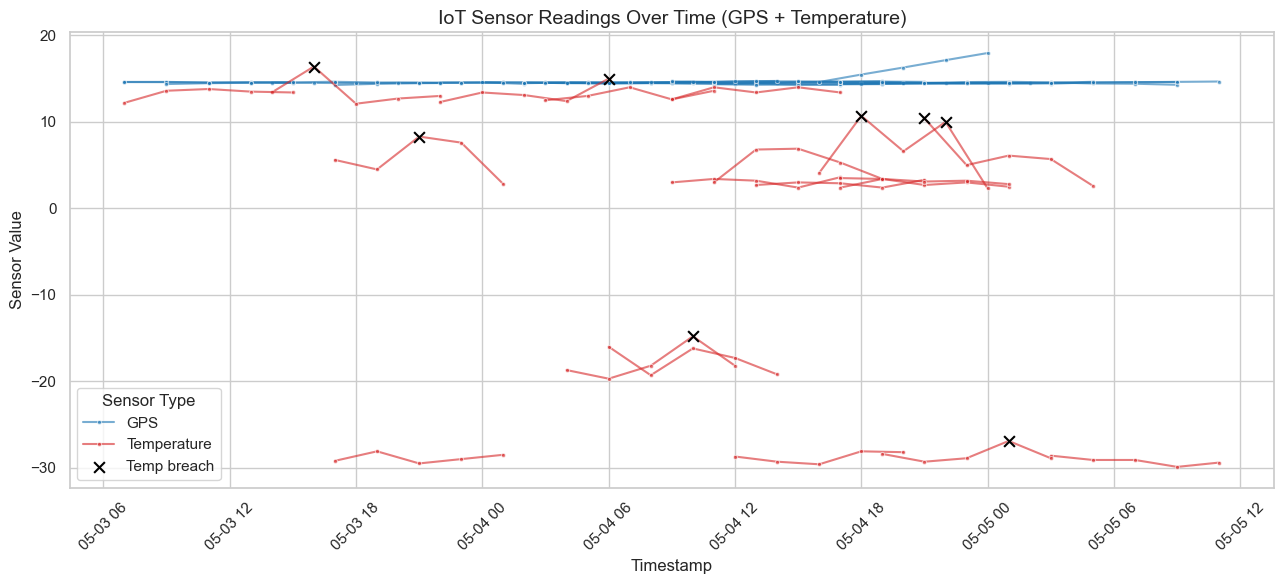

In [12]:
# Build a tidy long-form numeric_value column the way the template expects
plot_df = df.copy()
plot_df["numeric_value"] = np.where(
    plot_df["sensor_type"] == "GPS", plot_df["latitude"],
    np.where(plot_df["sensor_type"] == "Temperature", plot_df["temperature_c"], np.nan)
)
plot_df = plot_df.dropna(subset=["numeric_value"])

plt.figure(figsize=(13, 6))
sns.lineplot(
    data=plot_df, x="sensor_timestamp", y="numeric_value",
    hue="sensor_type", palette=SENSOR_COLORS,
    units="rfid_tag", estimator=None, marker="o", markersize=3, alpha=0.6,
)

# Overlay breach markers on the combined plot
breaches = plot_df[(plot_df["sensor_type"] == "Temperature") & (plot_df["temp_breach"] == True)]
plt.scatter(breaches["sensor_timestamp"], breaches["numeric_value"],
            color="black", marker="x", s=60, zorder=5, label="Temp breach")
plt.legend(title="Sensor Type")

plt.xticks(rotation=45)
plt.title("IoT Sensor Readings Over Time (GPS + Temperature)", fontsize=14)
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Sensor Value", fontsize=12)
plt.legend(title="Sensor Type")
plt.tight_layout()
plt.show()

## 5. Save the Plot

In [11]:
fig.savefig("../data/iot_sensor_readings_over_time.png", dpi=150, bbox_inches="tight")
print("Saved: data/iot_sensor_readings_over_time.png")

Saved: data/iot_sensor_readings_over_time.png
